## **0. INTRODUCTION**

Oleh: Achmad Baihaqie Wibowo (S1 Informatika Telkom University)

Tentang Dataset:
- Dataset berisi ribuan abstrak artikel medis yang diambil dari sumber literatur medis.
- Setiap abstrak telah diberi *label* ke dalam kategori tertentu berdasarkan kondisi medis atau penyakit yang dibahas.
- Abstrak dalam hal ini adalah ringkasan singkat dari penelitian kasus medis.
- Dataset berisi lima kelas target kondisi medis, di antaranya:
  - *Neoplasms* (Kanker/Tumor).
  - *Digestive System Diseases* (Penyakit Sistem Pencernaan).
  - *Nervous System Diseases* (Penyakit Sistem Saraf).
  - *Cardiovascular Diseases* (Penyakit Kardiovaskular/Jantung).
  - *General Pathological Conditions* (Kondisi Patologis Umum).

Tentang Proyek:
- Paradigma Pembelajaran: *Supervised Learning*.
- Jenis Tugas: *Multiclass Classification* dan/atau *Multilabel Classification*.
- Tipe Dataset: *Text*.
- *Tag*: *Natural Language Processing* (NLP), *Text Mining*.

Spesifikasi Proyek:
- Model Digunakan: Bio_ClinicalBERT.

Lampiran Tautan:
- Repositori GitHub:
- Model: https://huggingface.co/emilyalsentzer/Bio_ClinicalBERT
- Dataset: https://huggingface.co/datasets/TimSchopf/medical_abstracts

Catatan Kaki:
- Pengantar Praktis NLP: https://medium.com/@ageitgey/natural-language-processing-is-fun-9a0bff37854e
- Penelitian Serupa: https://arxiv.org/pdf/2411.12712
- EDA untuk Dataset Bertipe Teks: https://www.kaggle.com/code/harshsingh2209/complete-guide-to-eda-on-text-data/notebook
- `WeightedRandomSampler` untuk Kelas Tidak Seimbang: https://medium.com/data-science/demystifying-pytorchs-weightedrandomsampler-by-example-a68aceccb452
- Kelas Tidak Seimbang pada Kasus *Multilabel Classification*: https://discuss.pytorch.org/t/pos-weight-attribute-in-bcewithlogitloss/122882/4

Memahami *Term* Asing:
- *Corpus*: https://youtu.be/T3acR5BKJ2k?si=RY0ML-a-RX2k4PHh

## 1. Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from nltk.tokenize import sent_tokenize
import nltk
from transformers import AutoTokenizer
import torch
from sklearn.feature_extraction.text import CountVectorizer
import string
from nltk.corpus import stopwords
warnings.filterwarnings('ignore')

## 2. Load Data

In [2]:
# load: train, test, and labels
df_train = pd.read_csv('data/medical_tc_train.csv')
df_test = pd.read_csv('data/medical_tc_test.csv')
df_labels = pd.read_csv('data/medical_tc_labels.csv')

In [3]:
# merge: in order to get [condition_name] column
df_train = pd.merge(df_train, df_labels, on='condition_label', how='left')
df_test = pd.merge(df_test, df_labels, on='condition_label', how='left')

In [4]:
# preview: train
df_train.head()

,condition_label,medical_abstract,condition_name
0,5,Tissue changes around loose prostheses. A cani...,general pathological conditions
1,1,Neuropeptide Y and neuron-specific enolase lev...,neoplasms
2,2,"Sexually transmitted diseases of the colon, re...",digestive system diseases
3,1,Lipolytic factors associated with murine and h...,neoplasms
4,3,Does carotid restenosis predict an increased r...,nervous system diseases


In [5]:
# preview: test
df_test.head()

,condition_label,medical_abstract,condition_name
0,3,Obstructive sleep apnea following topical orop...,nervous system diseases
1,5,Neutrophil function and pyogenic infections in...,general pathological conditions
2,5,A phase II study of combined methotrexate and ...,general pathological conditions
3,1,Flow cytometric DNA analysis of parathyroid tu...,neoplasms
4,4,Paraneoplastic vasculitic neuropathy: a treata...,cardiovascular diseases


In [6]:
print(f'dimensi train set: {df_train.shape[0]} baris dan {df_train.shape[1]} kolom')
print(f'dimensi test set : {df_test.shape[0]} baris dan {df_test.shape[1]} kolom')

dimensi train set: 11550 baris dan 3 kolom
dimensi test set : 2888 baris dan 3 kolom


In [7]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11550 entries, 0 to 11549
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   condition_label   11550 non-null  int64 
 1   medical_abstract  11550 non-null  object
 2   condition_name    11550 non-null  object
dtypes: int64(1), object(2)
memory usage: 270.8+ KB


In [8]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2888 entries, 0 to 2887
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   condition_label   2888 non-null   int64 
 1   medical_abstract  2888 non-null   object
 2   condition_name    2888 non-null   object
dtypes: int64(1), object(2)
memory usage: 67.8+ KB


## 3. Exploratory Data Analysis

### 3.1 Class Distribution

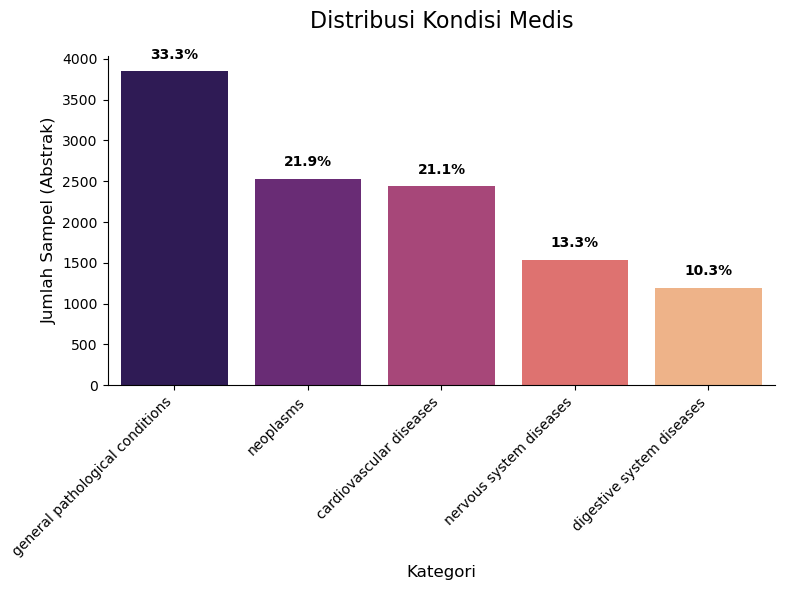

In [9]:
plt.figure(figsize=(8, 6), dpi=100)
ax = sns.countplot(
    data=df_train, 
    x='condition_name', 
    order=df_train['condition_name'].value_counts().index, 
    palette='magma'
)

# add percentage as a label on each bar
for p in ax.patches:
    # calculate percentage
    percentage = f'{100 * p.get_height() / len(df_train):.1f}%'
    # determine the position
    x = p.get_x() + p.get_width() / 2 # the middle of bar
    y = p.get_height() + (len(df_train) * 0.01) # little above a bar
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Distribusi Kondisi Medis', fontsize=16, pad=20)
plt.xlabel('Kategori', fontsize=12)
plt.ylabel('Jumlah Sampel (Abstrak)', fontsize=12)
plt.xticks(rotation=45, ha='right')
sns.despine()
plt.tight_layout()
plt.show()

*Inference*: Terdapat ketidakseimbangan kelas pada variabel target.

### 3.2 Check for Missing Value

In [10]:
df_train.isnull().sum()

condition_label     0
medical_abstract    0
condition_name      0
dtype: int64

In [11]:
df_test.isnull().sum()

condition_label     0
medical_abstract    0
condition_name      0
dtype: int64

Inference: Tidak terdapat *missing values* apapun.

### 3.3 Bivariate Analysis: Abstract Text vs Label Associated

In [12]:
conflicting_labels = df_train.groupby('medical_abstract')['condition_label'].nunique()
print(f"banyaknya [teks secara unik berasosiasi dengan lebih dari satu label] pada train set: {(conflicting_labels > 1).sum()}")

banyaknya [teks secara unik berasosiasi dengan lebih dari satu label] pada train set: 1956


In [13]:
conflicting_labels = df_test.groupby('medical_abstract')['condition_label'].nunique()
print(f"banyaknya [teks secara unik berasosiasi dengan lebih dari satu label] pada test set: {(conflicting_labels > 1).sum()}")

banyaknya [teks secara unik berasosiasi dengan lebih dari satu label] pada test set: 113


Total Abstrak Unik dalam Dataset  : 9,445
Abstrak dengan Label Tunggal       : 7,489
Abstrak dengan Potensi Multilabel  : 1,956


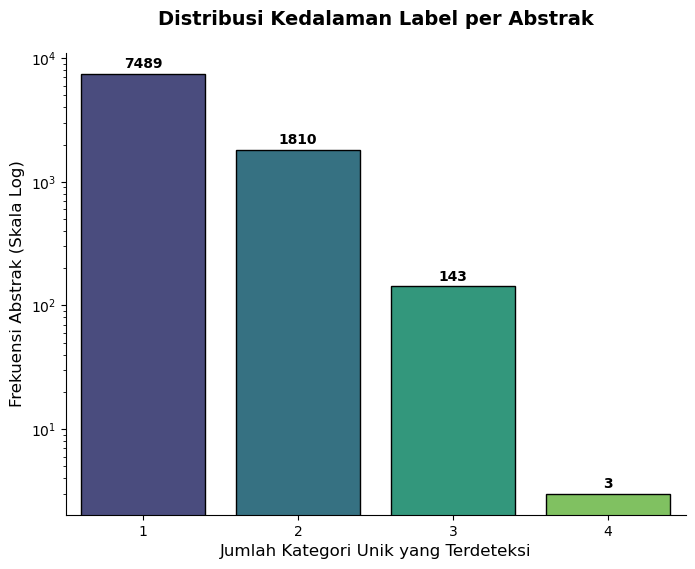

In [15]:
# label consolidation: Grouping all labels associated with the same abstract
df_konsolidasi = df_train.groupby('medical_abstract')['condition_label'].apply(list).reset_index()
# calculate amount of unique label
df_konsolidasi['jumlah_label_unik'] = df_konsolidasi['condition_label'].apply(lambda x: len(set(x)))
# abstract with multilabel associated
df_ambigu = df_konsolidasi[df_konsolidasi['jumlah_label_unik'] > 1]
# display info
print(f"Total Abstrak Unik dalam Dataset  : {len(df_konsolidasi):,}")
print(f"Abstrak dengan Label Tunggal       : {len(df_konsolidasi[df_konsolidasi['jumlah_label_unik'] == 1]):,}")
print(f"Abstrak dengan Potensi Multilabel  : {len(df_ambigu):,}")
# label distribution per abstract
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df_konsolidasi, x='jumlah_label_unik', palette='viridis', edgecolor='black')
plt.yscale('log') 
plt.title('Distribusi Kedalaman Label per Abstrak', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Jumlah Kategori Unik yang Terdeteksi', fontsize=12)
plt.ylabel('Frekuensi Abstrak (Skala Log)', fontsize=12)
# add number of asbtract as a label on each bar
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}', 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', 
        va='center', 
        fontsize=10, 
        color='black', 
        fontweight='bold', 
        xytext=(0, 7), 
        textcoords='offset points'
    )
sns.despine()
plt.show()

*Inference*: Kemungkinan akan dibuat beberapa *approach* untuk menyelesaikan proyek sederhana ini, yakni salah duanya *multiclass classification* dan *multilabel classification*.

### 3.4 Identify Length of Components of Text

In [16]:
def describe_numerical_features_full(df, features):
    summary = []
    for col in features:
        s = df[col].dropna()
        summary.append({
            'Feature': col,
            'Mean': s.mean(),
            'Median': s.median(),
            'Mode': s.mode().iloc[0] if not s.mode().empty else None,
            'Min': s.min(),
            'Q1': s.quantile(0.25),
            'Q3': s.quantile(0.75),
            'Max': s.max(),
            'IQR': s.quantile(0.75) - s.quantile(0.25),
            'Variance': s.var(),
            'Std_Dev': s.std(),
            'Skewness': s.skew(),
            'Kurtosis': s.kurt()
        })
    return pd.DataFrame(summary)

temp_eda_df = df_train.copy()
temp_eda_df['char_count'] = temp_eda_df['medical_abstract'].apply(len)
temp_eda_df['word_count'] = temp_eda_df['medical_abstract'].apply(lambda x: len(str(x).split()))
temp_eda_df['mean_word_length'] = temp_eda_df['medical_abstract'].apply(lambda x: np.mean([len(word) for word in str(x).split()]) if len(str(x).split()) > 0 else 0)
temp_eda_df['mean_sentence_length'] = temp_eda_df['medical_abstract'].apply(lambda x: np.mean([len(sent) for sent in sent_tokenize(str(x))]) if len(sent_tokenize(str(x))) > 0 else 0)

stats_summary = describe_numerical_features_full(temp_eda_df, ['char_count', 'word_count', 'mean_word_length', 'mean_sentence_length'])
print("Stats: Length of Components of Abstract Text")
display(stats_summary)

Stats: Length of Components of Abstract Text


,Feature,Mean,Median,Mode,Min,Q1,Q3,Max,IQR,Variance,Std_Dev,Skewness,Kurtosis
0,char_count,1229.104156,1208.000000,1034.0,170.000000,847.000000,1587.000000,3999.000000,740.000000,255996.515170,505.960982,0.353794,0.029811
1,word_count,179.640606,175.000000,169.0,24.000000,122.000000,234.000000,596.000000,112.000000,5832.342641,76.369776,0.358311,-0.052326
2,mean_word_length,5.906711,5.878049,6.0,4.500000,5.594595,6.184851,8.326923,0.590257,0.207063,0.455042,0.414629,0.596534
3,mean_sentence_length,143.007391,139.166667,121.0,45.666667,118.600000,163.363636,409.333333,44.763636,1244.153864,35.272565,0.752766,1.476178


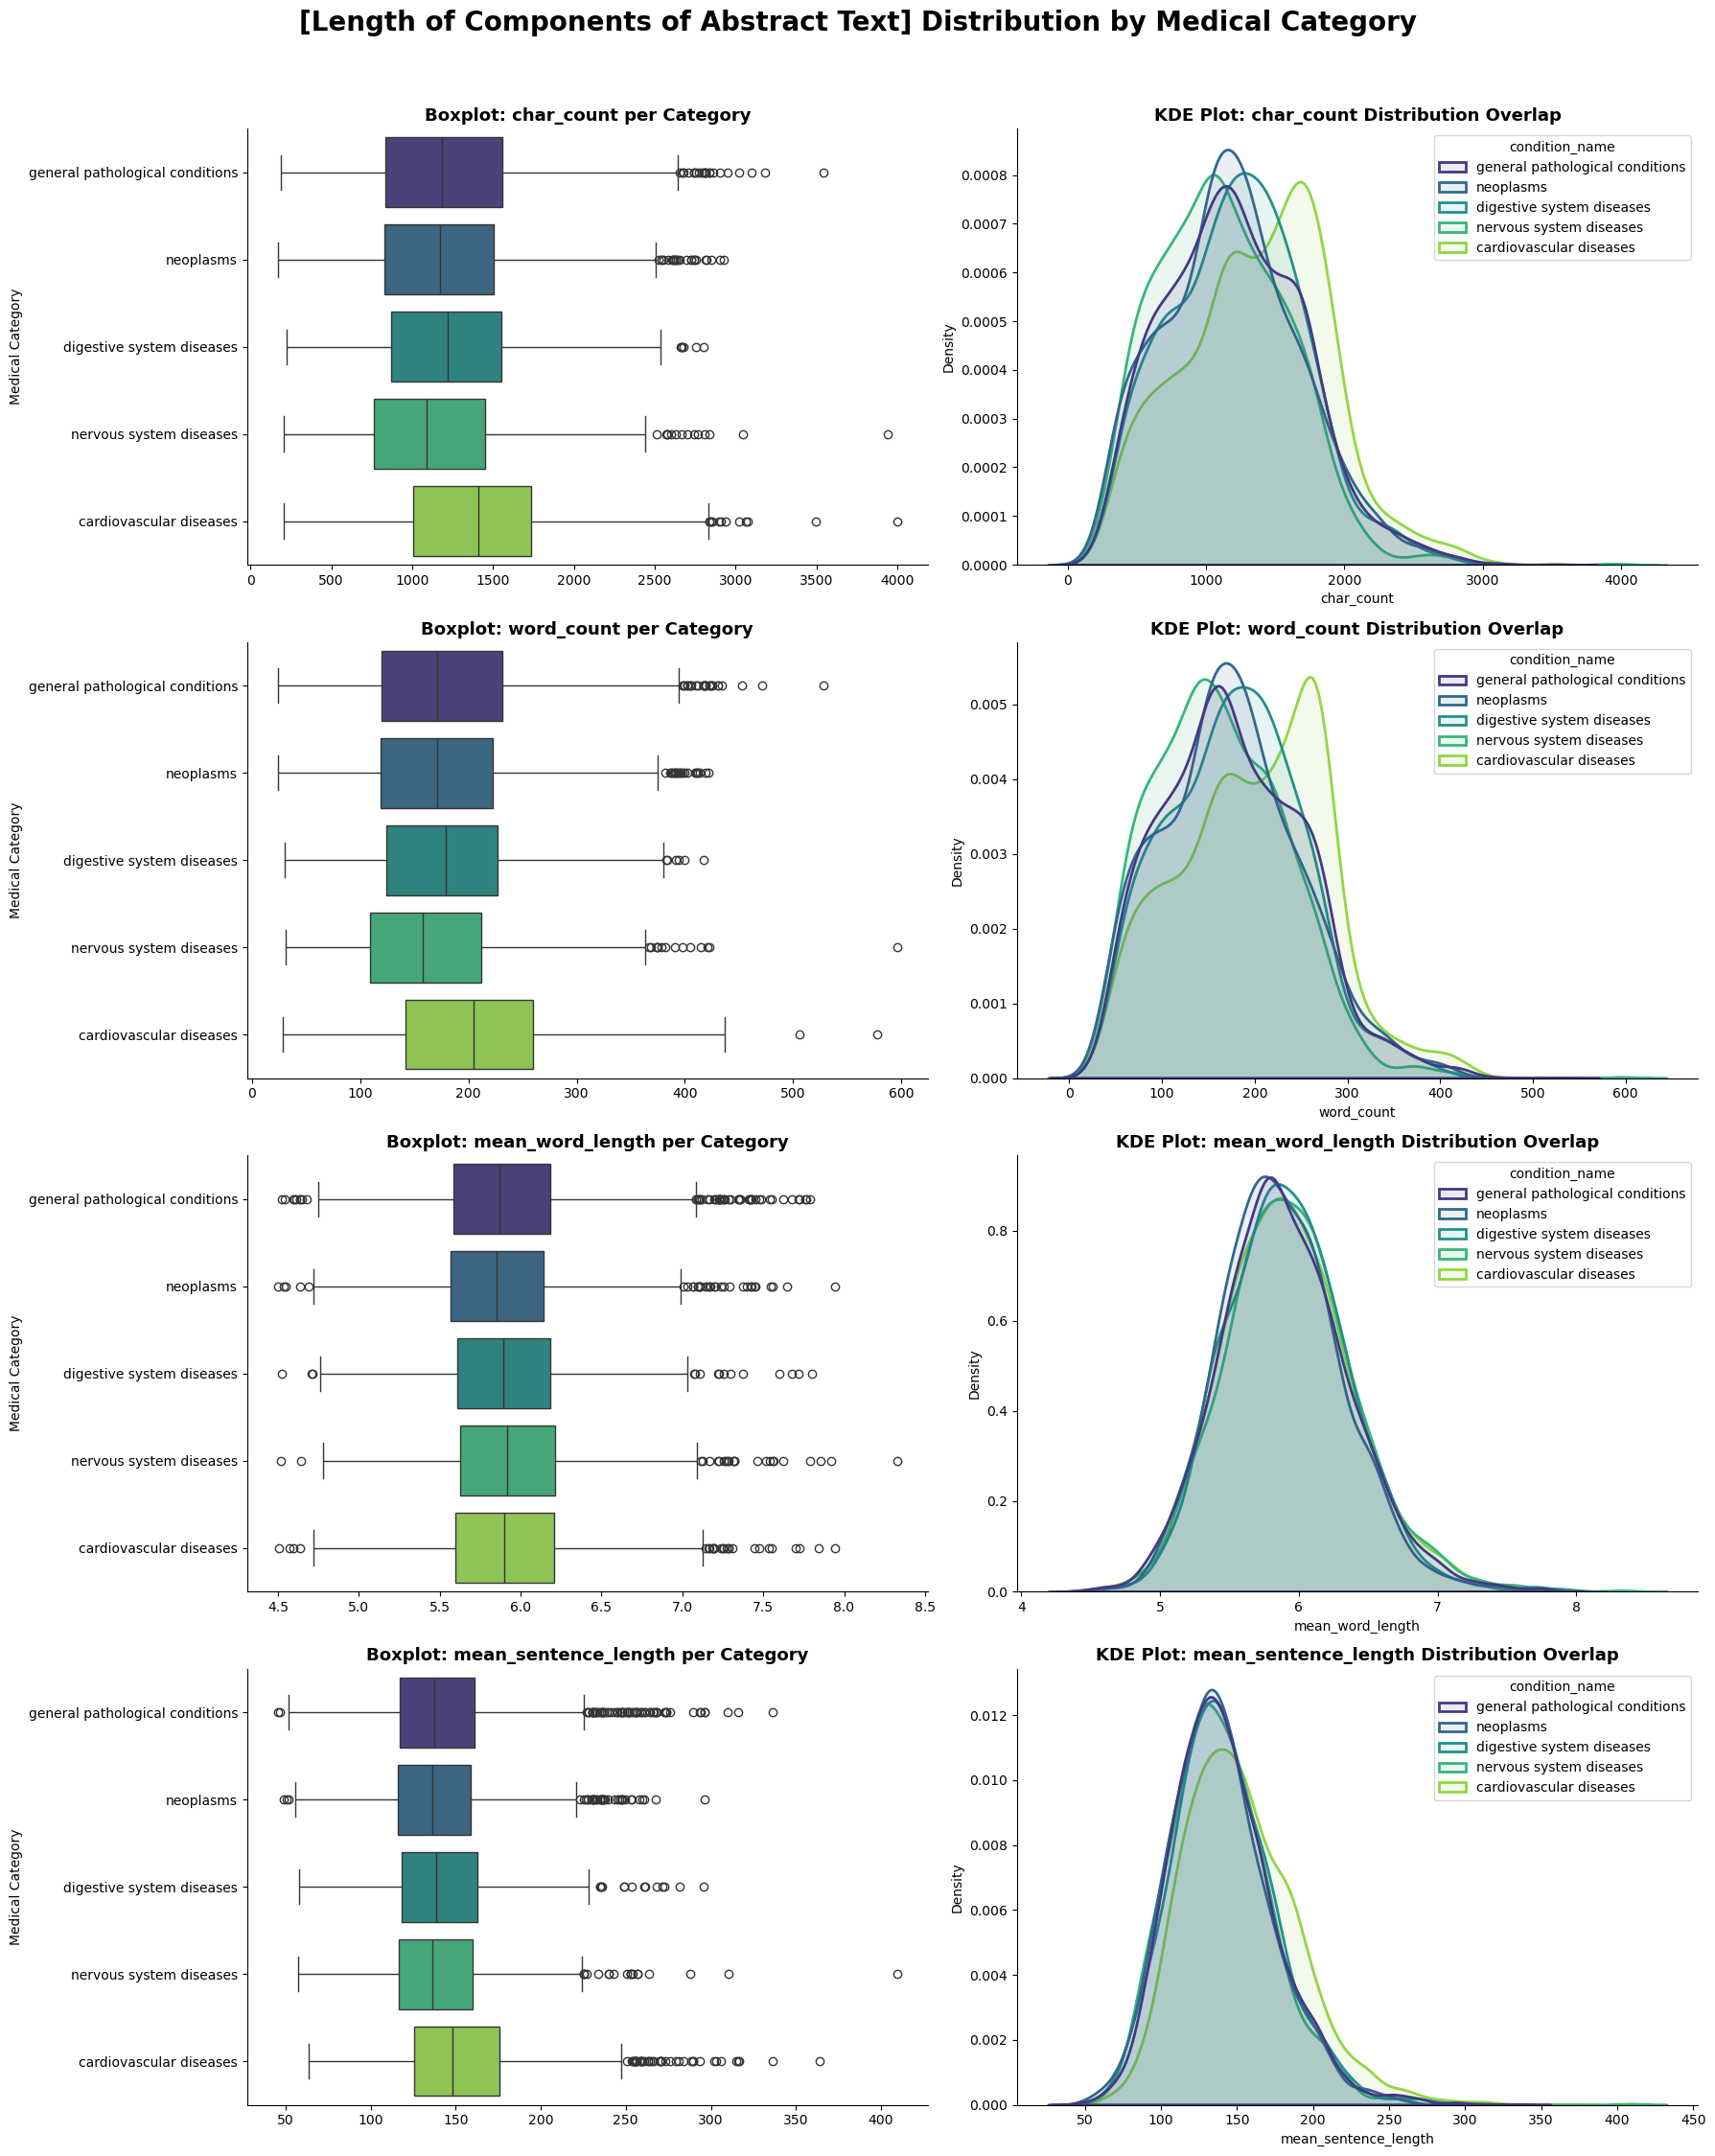

In [17]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(18, 22), dpi=100)
for i, col in enumerate(['char_count', 'word_count', 'mean_word_length', 'mean_sentence_length']):
    # boxplot
    sns.boxplot(
        data=temp_eda_df, 
        x=col, 
        y='condition_name', 
        ax=axes[i, 0], 
        palette='viridis', 
        hue='condition_name', 
        legend=False
    )
    axes[i, 0].set_title(f'Boxplot: {col} per Category', fontsize=13, fontweight='bold')
    axes[i, 0].set_ylabel('Medical Category')
    axes[i, 0].set_xlabel(None)

    # KDE plot
    sns.kdeplot(
        data=temp_eda_df, 
        x=col, 
        hue='condition_name', 
        ax=axes[i, 1], 
        fill=True, 
        palette='viridis', 
        common_norm=False, 
        alpha=0.1,      
        linewidth=2       
    )
    axes[i, 1].set_title(f'KDE Plot: {col} Distribution Overlap', fontsize=13, fontweight='bold')
    axes[i, 1].set_ylabel('Density')
    axes[i, 1].set_xlabel(col)

sns.despine()
plt.suptitle('[Length of Components of Abstract Text] Distribution by Medical Category', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.5 Term Frequency Analysis and Most Frequently occuring N_grams

In [18]:
# initialize stop_words
stop_words = set(stopwords.words('english'))

def preprocess_text_for_eda(text):
    # lowercase
    text = str(text).lower()
    # remove punctuatuion
    text = text.translate(str.maketrans('', '', string.punctuation))
    # tokenize & remove stopwords
    words = text.split()
    words = [w for w in words if w not in stop_words and w.isalpha()]
    return " ".join(words)

clean_temp_eda_df = temp_eda_df['medical_abstract'].apply(preprocess_text_for_eda)

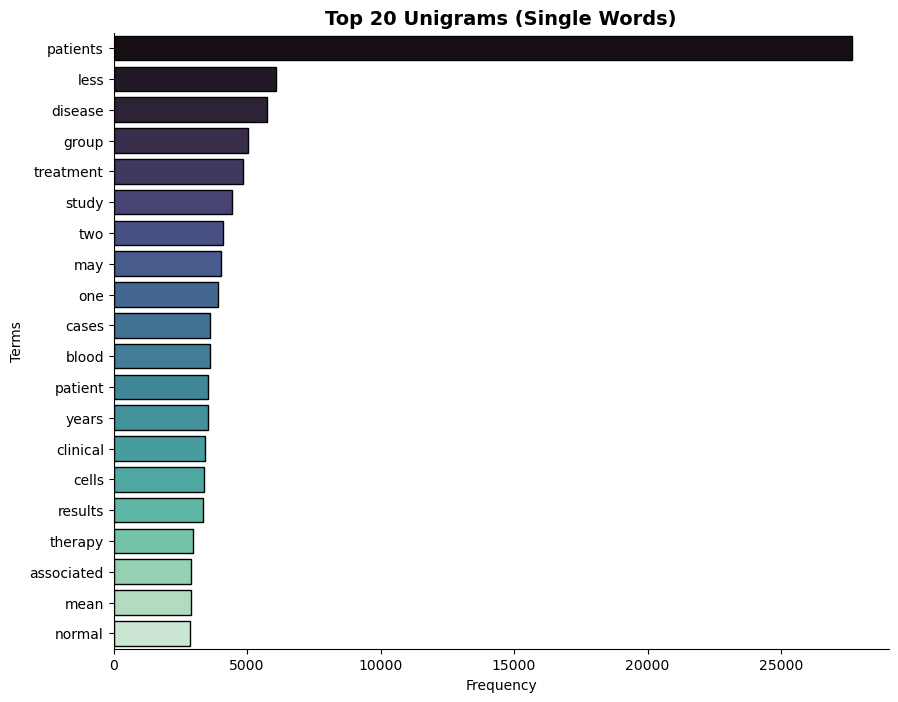

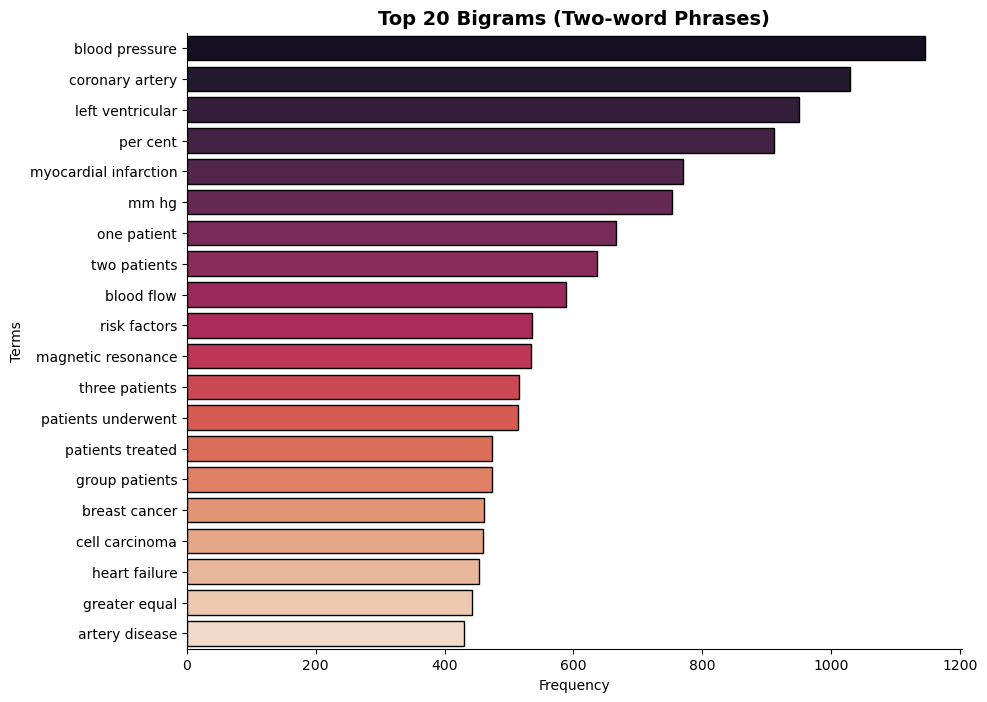

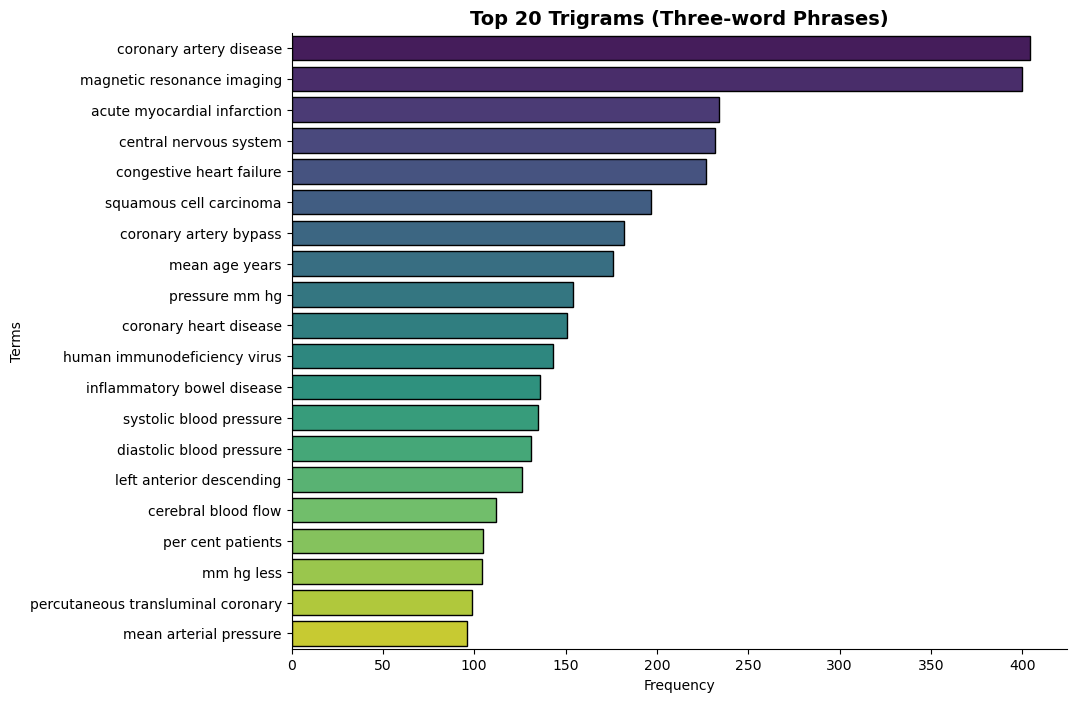

In [20]:
def plot_medical_ngrams(texts, n=1, title="Top Occurrences", color='mako'):
    # initialize vectorizer
    vec = CountVectorizer(ngram_range=(n, n)).fit(texts)
    bag_of_words = vec.transform(texts)
    sum_words = bag_of_words.sum(axis=0) 
    
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:20]
    
    df_ngram = pd.DataFrame(words_freq, columns=['term', 'frequency'])
    
    plt.figure(figsize=(10, 8))
    sns.barplot(data=df_ngram, x='frequency', y='term', palette=color, edgecolor='black')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Frequency')
    plt.ylabel('Terms')
    sns.despine()
    plt.show()

plot_medical_ngrams(clean_temp_eda_df, n=1, title="Top 20 Unigrams (Single Words)", color='mako')
plot_medical_ngrams(clean_temp_eda_df, n=2, title="Top 20 Bigrams (Two-word Phrases)", color='rocket')
plot_medical_ngrams(clean_temp_eda_df, n=3, title="Top 20 Trigrams (Three-word Phrases)", color='viridis')

### 3.6 Token Length Analysis

In [21]:
# initialize Bio_ClinicalBERT tokenizer
tokenizer = AutoTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")

# token length calculation
temp_eda_df['token_count'] = temp_eda_df['medical_abstract'].apply(lambda x: len(tokenizer.encode(str(x), add_special_tokens=True)))

# descriptive statistics
print("\nStats: Token Length")
display(temp_eda_df['token_count'].describe())


Stats: Token Length


count    11550.000000
mean       293.274113
std        129.099072
min         38.000000
25%        194.000000
50%        283.000000
75%        380.000000
max        880.000000
Name: token_count, dtype: float64

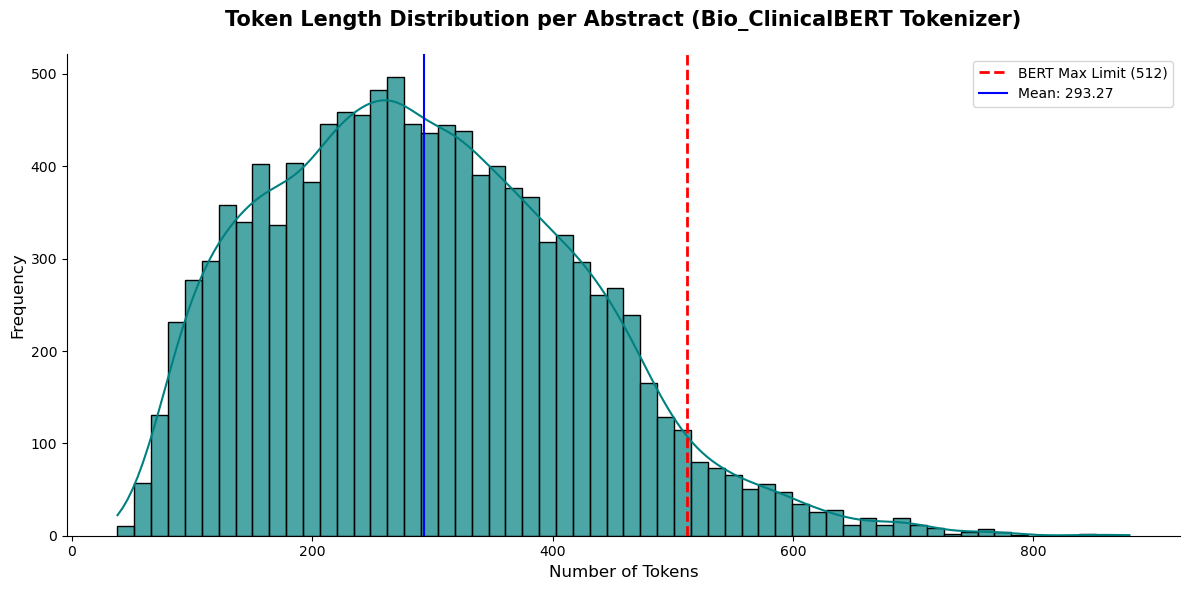

In [22]:
# token length distribution
plt.figure(figsize=(12, 6), dpi=100)
sns.histplot(temp_eda_df['token_count'], bins=60, kde=True, color='teal', edgecolor='black', alpha=0.7)
# BERT maximum limit line (512 tokens)
plt.axvline(512, color='red', linestyle='--', linewidth=2, label='BERT Max Limit (512)')
# annotate mean & median
plt.axvline(temp_eda_df['token_count'].mean(), color='blue', linestyle='-', label=f"Mean: {temp_eda_df['token_count'].mean():.2f}")
plt.title('Token Length Distribution per Abstract (Bio_ClinicalBERT Tokenizer)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Number of Tokens', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

In [23]:
# truncation analysis
truncated_count = (temp_eda_df['token_count'] > 512).sum()
total_count = len(temp_eda_df)
truncation_percentage = (truncated_count / total_count) * 100
print(f"batas maksimum token (Bio_ClinicalBERT)  : 512 tokens")
print(f"total sampel dalam dataset               : {total_count:,} abstrak")
print(f"sampel yang melebihi batas (truncated)   : {truncated_count:,} abstrak")
print(f"persentase data yang akan terpotong      : {truncation_percentage:.2f}%")

batas maksimum token (Bio_ClinicalBERT)  : 512 tokens
total sampel dalam dataset               : 11,550 abstrak
sampel yang melebihi batas (truncated)   : 587 abstrak
persentase data yang akan terpotong      : 5.08%
